<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v2/blob/master/Teacher_ResNet_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 · Teacher Candidate — ResNet (from scratch)

Custom lightweight ResNet (4 residual stages, BasicBlock) trained from random
initialization on VWW.

**Architecture:** stem → layer1(32) → layer2(64) → layer3(128) → layer4(256) → GAP → fc
~0.7M parameters. Residual connections provide better gradient flow than the VGG scratch
baseline, expected to outperform it despite fewer parameters.


In [1]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place the utils/ folder at: My Drive/thesis/utils/")


Mounted at /content/drive
✅ utils loaded from Drive


In [2]:
# ── Standard imports ────────────────────────────────────────────────
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from utils.dataset import prepare_dataset, get_loaders, get_test_loader
from utils.models  import (
    VGG_Scratch, VGG_Pretrained,
    ResNet_Scratch, ResNet18_Pretrained,
    MobileNetV2_Scratch, MobileNetV3_Pretrained,
    count_params, model_size_mb, MODEL_REGISTRY,
)
from utils.train import (
    setup_device, set_seed, evaluate,
    train_model, train_model_three_phase,
    train_multi_seed, train_kd, plot_history,
)

device = setup_device(seed=41)


Device: cuda


In [3]:
# ── Dataset setup ───────────────────────────────────────────────────
prepare_dataset()


1/4 Download
⬇️  Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
2/4 Extract
📦 Extracting VWW archive...
✅ Extraction complete: /content/vww_work/extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests


PosixPath('/content/vww_work/extracted/vw_coco2014_96')

## Standardized hyperparameters

All models use identical settings to ensure fair comparison:

| Parameter | Scratch models | Pretrained models |
|-----------|---------------|-------------------|
| Batch size | 64 | 64 |
| Optimizer | Adam | Adam |
| Weight decay | 1e-4 | 1e-4 |
| Label smoothing | 0.1 | 0.1 |
| Augmentation | standard | standard |
| Scheduler | CosineAnnealingLR | CosineAnnealingLR |
| Patience | 10 | 10 |
| Seeds | [41, 52, 63] | [41, 52, 63] |
| Max epochs | 50 | 30 |
| LR | 1e-3 | 3e-4 → 1e-4 → 3e-5 (3-phase) |

Pretrained models use fewer max epochs because transfer learning converges faster.
The three-phase progressive unfreeze is only applicable to pretrained models.


In [4]:
SAVE_DIR = "/content/drive/My Drive/Colab Notebooks"


In [5]:
train_loader, val_loader = get_loaders(batch_size=64, augmentation="standard")


Train: 7000 | Val: 1500 | Batch: 64


In [6]:
results, best = train_multi_seed(
    model_fn     = ResNet_Scratch,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    seeds        = [41, 52, 63],
    save_dir     = SAVE_DIR,
    name_prefix  = "resnet_scratch",
    pretrained   = False,
    epochs          = 50,
    lr              = 1e-3,
    weight_decay    = 1e-4,
    label_smoothing = 0.1,
    patience        = 10,
)



Seed 41
Epoch   1/50 | LR 0.000999 | Train 58.40% | Val 61.87% ✅
Epoch   2/50 | LR 0.000996 | Train 61.41% | Val 61.80%
Epoch   3/50 | LR 0.000991 | Train 62.80% | Val 53.27%
Epoch   4/50 | LR 0.000984 | Train 64.53% | Val 61.07%
Epoch   5/50 | LR 0.000976 | Train 65.99% | Val 64.20% ✅
Epoch   6/50 | LR 0.000965 | Train 67.11% | Val 65.93% ✅
Epoch   7/50 | LR 0.000952 | Train 68.19% | Val 65.60%
Epoch   8/50 | LR 0.000938 | Train 68.69% | Val 67.40% ✅
Epoch   9/50 | LR 0.000922 | Train 69.30% | Val 70.27% ✅
Epoch  10/50 | LR 0.000905 | Train 70.13% | Val 67.87%
Epoch  11/50 | LR 0.000885 | Train 69.81% | Val 69.00%
Epoch  12/50 | LR 0.000864 | Train 70.44% | Val 71.87% ✅
Epoch  13/50 | LR 0.000842 | Train 71.19% | Val 67.60%
Epoch  14/50 | LR 0.000819 | Train 71.96% | Val 71.33%
Epoch  15/50 | LR 0.000794 | Train 72.29% | Val 73.40% ✅
Epoch  16/50 | LR 0.000768 | Train 73.27% | Val 71.67%
Epoch  17/50 | LR 0.000741 | Train 72.66% | Val 72.60%
Epoch  18/50 | LR 0.000713 | Train 73.04% 

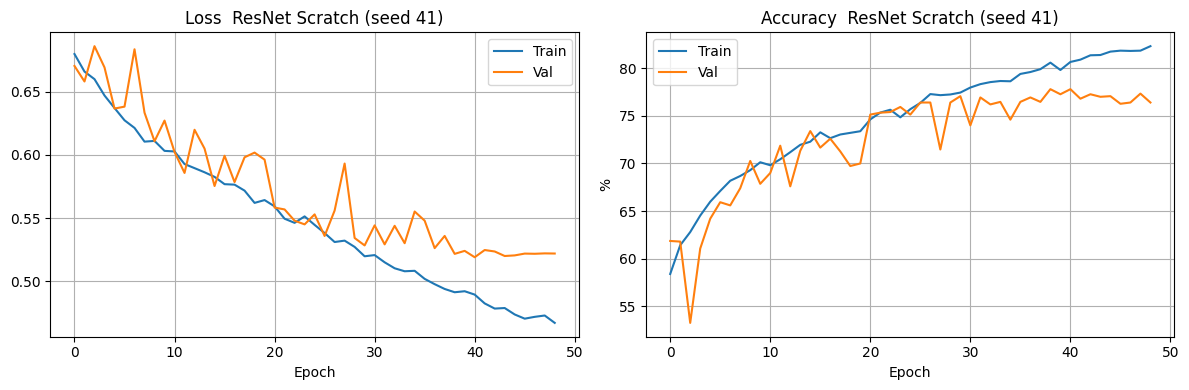

Best: 77.80% @ epoch 39  (20.3 min)

ResNet Scratch  |  Mean: 77.36% ± 0.58%  |  Best: 77.80% (seed 41)
Best checkpoint: /content/drive/My Drive/Colab Notebooks/resnet_scratch_seed_41.pth


In [7]:
plot_history(best, title=f"ResNet Scratch (seed {best['seed']})")

accs = [r["best_acc"] for r in results]
print(f"\nResNet Scratch  |  Mean: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%  |  "
      f"Best: {best['best_acc']*100:.2f}% (seed {best['seed']})")
print(f"Best checkpoint: {best['save_path']}")
